In [18]:
import sys
import os

# Kaynak dosyaların bulunduğu klasörü path'e ekle
sys.path.insert(0, os.path.abspath("../"))  # Gerekirse klasör yolunu buraya yaz

from src.models.preprocessing import (
    load_raw_data,
    stratified_sample,
    build_url_feature_dataframe,
    prepare_features_and_labels,
    Preprocessor,
    get_train_test_split,
    get_kfold_splits,
) #Burada src klasöründeki preprocessing modülünden gerekli fonksiyonları import ediyoruz. 
#İşlemler modülde yapılacak ve bu fonksiyonlar burada kullanılacak.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Tüm modüller başarıyla import edildi.")

✅ Tüm modüller başarıyla import edildi.


In [19]:
CSV_PATH      = "../data/raw/malicious_phish.csv"        # ← kendi yolun
LABEL_COLUMN  = "label"           # ← kendi label sütunun
POSITIVE_LABEL = "positive"       # ← binary ise doldur, değilse None
NEGATIVE_LABEL = "negative"       # ← binary ise doldur, değilse None

df_raw = load_raw_data(CSV_PATH)
print(f"✅ Veri yüklendi: {df.shape}")
display(df.head())

✅ Veri yüklendi: (100000, 2)


,url,type
0,solucaoassessoriaservicos.com,phishing
1,www.bom.gov.au/marine/,phishing
2,https://meganmacylesolutions.com/secure/login....,phishing
3,https://docs.google.com/spreadsheet/viewform?f...,phishing
4,jakarta.apache.org/bsf/,phishing


type
benign        428103
defacement     96457
phishing       94111
malware        32520


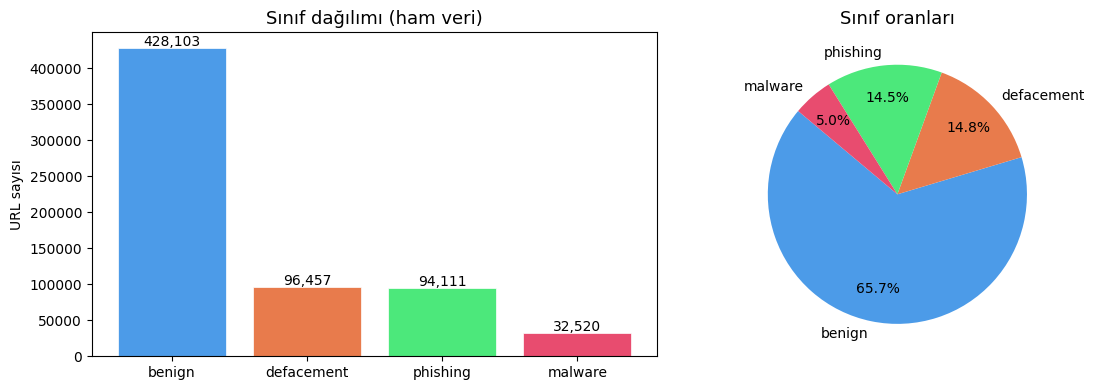

In [20]:
dist = df_raw['type'].value_counts()
print(dist.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#4C9BE8', '#E87B4C', '#4CE87B', '#E84C6F']

axes[0].bar(dist.index, dist.values, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Sınıf dağılımı (ham veri)', fontsize=13)
axes[0].set_ylabel('URL sayısı')
for i, (cls, cnt) in enumerate(dist.items()):
    axes[0].text(i, cnt + 3000, f'{cnt:,}', ha='center', fontsize=10)

axes[1].pie(dist.values, labels=dist.index, autopct='%1.1f%%',
            colors=colors, startangle=140, pctdistance=0.75)
axes[1].set_title('Sınıf oranları', fontsize=13)

plt.tight_layout()
plt.show()

In [21]:
N_PER_CLASS = 25_000

df = stratified_sample(df_raw, label_column='type', n_per_class=N_PER_CLASS)

print('Örneklem sonrası dağılım:')
print(df['type'].value_counts().to_string())
print(f'\nToplam örnek: {len(df):,}')

Örneklem sonrası dağılım:
type
phishing      25000
benign        25000
defacement    25000
malware       25000

Toplam örnek: 100,000


In [22]:
df_features = build_url_feature_dataframe(df, url_column='url')
feature_cols = [c for c in df_features.columns if c != 'type']
df_features.head()

⏳ URL feature extraction çalışıyor...
✅ Feature extraction tamamlandı: (100000, 22)
   Sütunlar: ['url_len', 'dot_count', 'slash_count', 'dash_count', 'digit_count', 'letter_count', 'digit_ratio', 'has_https', 'has_http', 'has_at', 'has_ip', 'has_port', 'has_encoded_chars', 'has_suspicious', 'tld_len', 'subdomain_count', 'domain_len', 'path_depth', 'query_len', 'special_ratio', 'entropy', 'type']


,url_len,dot_count,slash_count,dash_count,digit_count,letter_count,digit_ratio,has_https,has_http,has_at,...,has_encoded_chars,has_suspicious,tld_len,subdomain_count,domain_len,path_depth,query_len,special_ratio,entropy,type
0,29,1,0,0,0,28,0.000000,0,0,0,...,0,0,3,0,29,0,0,0.000000,3.245191,phishing
1,22,3,2,0,0,17,0.000000,0,0,0,...,0,0,2,2,14,0,0,0.000000,3.663533,phishing
2,83,5,5,0,0,72,0.000000,1,1,0,...,0,1,3,0,24,3,0,0.012048,4.122533,phishing
3,87,2,4,0,3,75,0.034483,1,1,0,...,0,0,3,1,15,2,42,0.034483,5.051465,phishing
4,23,2,2,0,0,19,0.000000,0,0,0,...,0,0,3,1,18,0,0,0.000000,3.757925,phishing


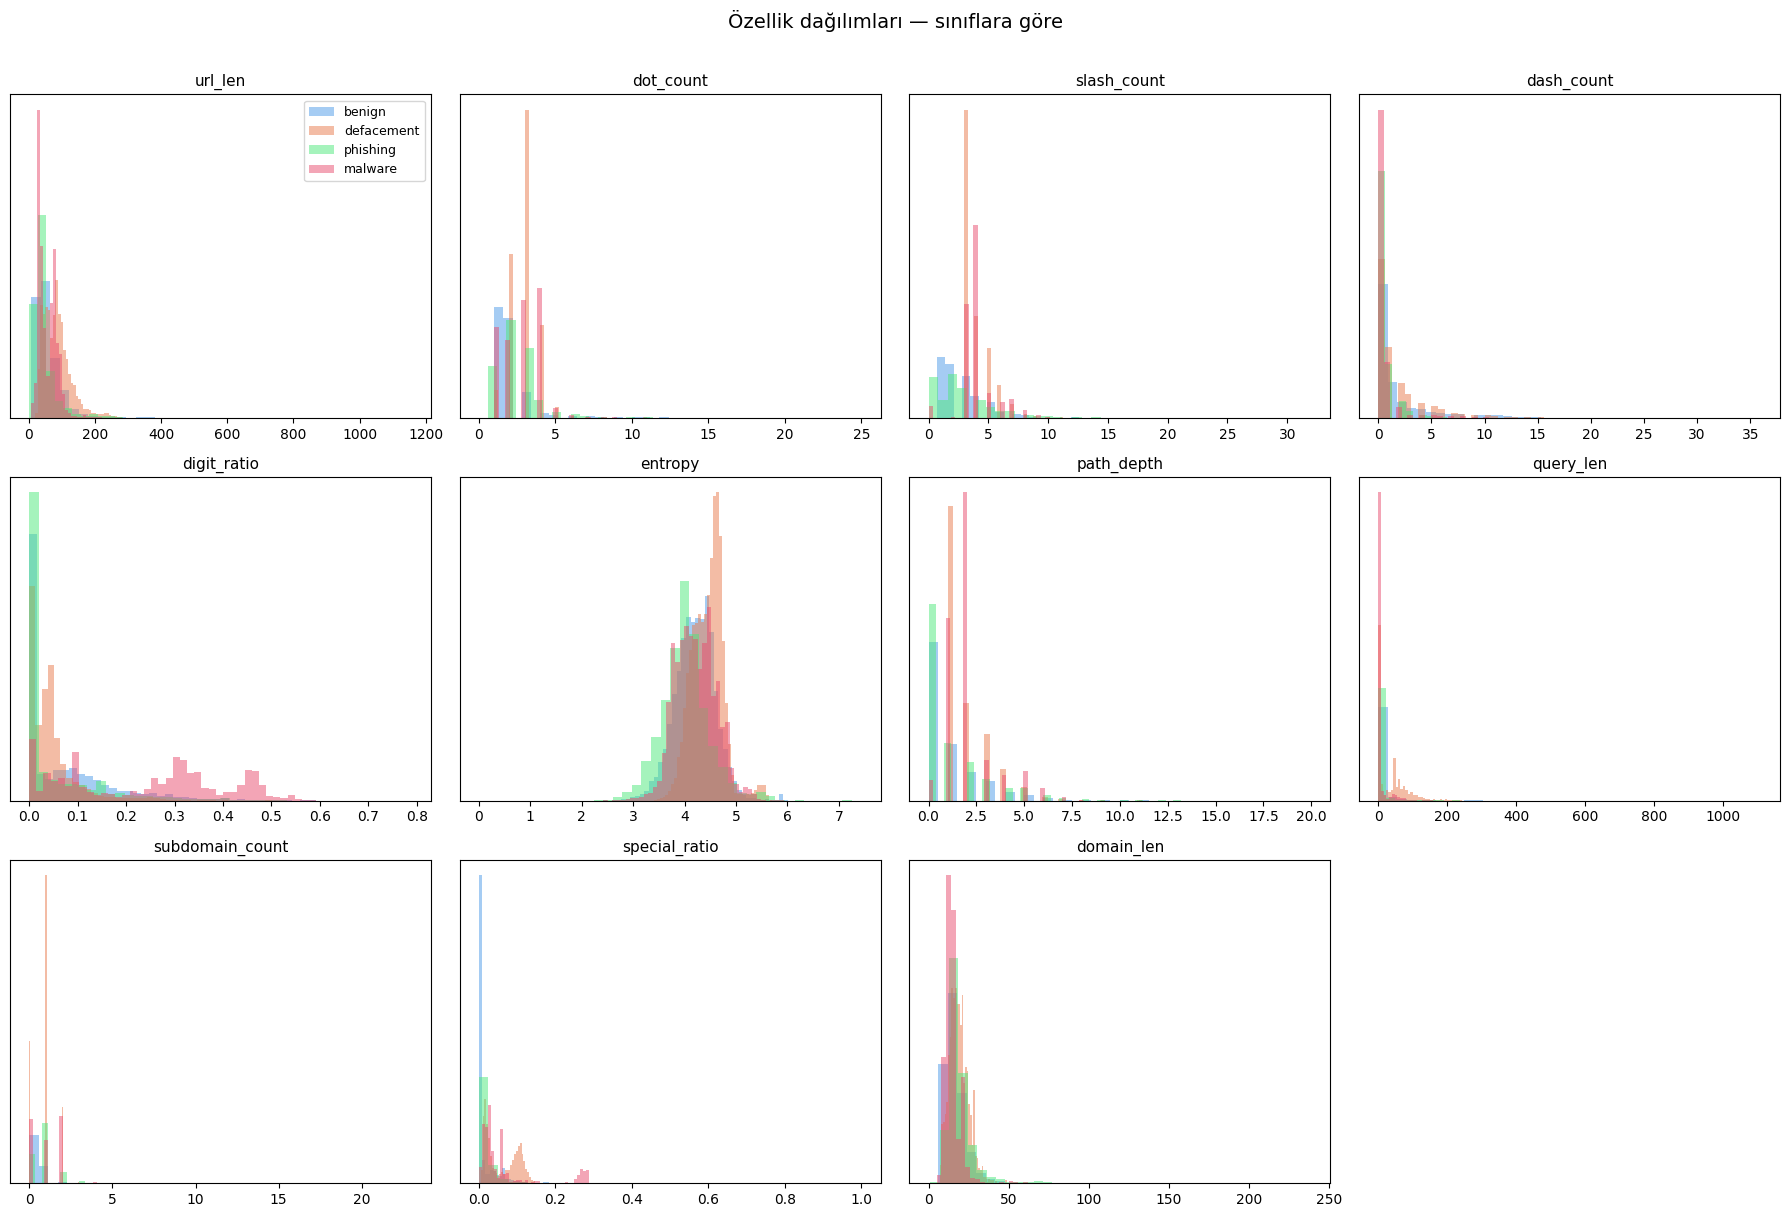

In [23]:
numeric_feats = ['url_len', 'dot_count', 'slash_count', 'dash_count',
                 'digit_ratio', 'entropy', 'path_depth', 'query_len',
                 'subdomain_count', 'special_ratio', 'domain_len']

palette = {'benign': '#4C9BE8', 'defacement': '#E87B4C',
           'phishing': '#4CE87B', 'malware': '#E84C6F'}

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, feat in enumerate(numeric_feats):
    for cls, clr in palette.items():
        subset = df_features[df_features['type'] == cls][feat]
        axes[i].hist(subset, bins=40, alpha=0.5, color=clr, label=cls, density=True)
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_yticks([])

axes[0].legend(fontsize=9)
axes[-1].set_visible(False)
plt.suptitle('Özellik dağılımları — sınıflara göre', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

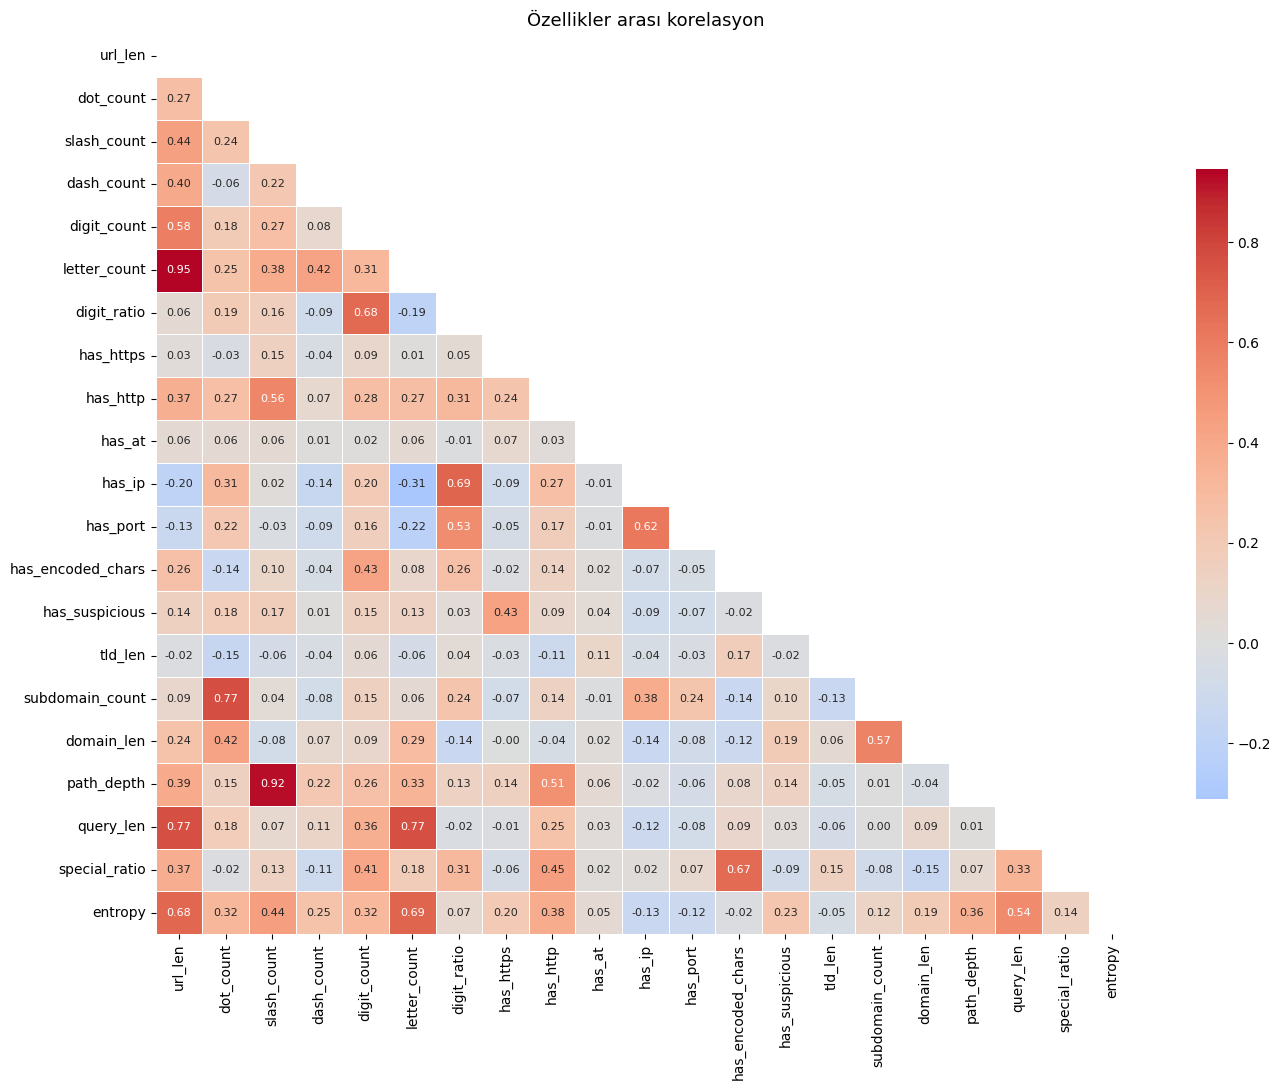

In [24]:
corr = df_features[feature_cols].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.7})
plt.title('Özellikler arası korelasyon', fontsize=13)
plt.tight_layout()
plt.show()

In [25]:
X, y = prepare_features_and_labels(df_features, label_column='type')

print(f'X şekli : {X.shape}')
print(f'y şekli : {y.shape}')
print(f'Sınıf değerleri: {np.unique(y)}  →  0=benign 1=defacement 2=malware 3=phishing')

ℹ️  Otomatik etiket haritası: {'benign': 0, 'defacement': 1, 'malware': 2, 'phishing': 3}
X şekli : (100000, 21)
y şekli : (100000,)
Sınıf değerleri: [0 1 2 3]  →  0=benign 1=defacement 2=malware 3=phishing


In [26]:
X_train, X_test, y_train, y_test = get_train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=True
)

print(f'Train : {X_train.shape[0]:,} örnek')
print(f'Test  : {X_test.shape[0]:,} örnek')
print('Train sınıf dağılımı:', dict(zip(*np.unique(y_train, return_counts=True))))
print('Test  sınıf dağılımı:', dict(zip(*np.unique(y_test,  return_counts=True))))

Train : 80,000 örnek
Test  : 20,000 örnek
Train sınıf dağılımı: {np.int64(0): np.int64(20000), np.int64(1): np.int64(20000), np.int64(2): np.int64(20000), np.int64(3): np.int64(20000)}
Test  sınıf dağılımı: {np.int64(0): np.int64(5000), np.int64(1): np.int64(5000), np.int64(2): np.int64(5000), np.int64(3): np.int64(5000)}


In [27]:
prep = Preprocessor(
    apply_minmax=True,
    apply_l2=True,
    n_pca_components=None,  # PCA için: 0.95 (varyans oranı) veya int (sabit sayı)
)

X_train_proc = prep.fit_transform(X_train)
X_test_proc  = prep.transform(X_test)

print(f'Train şekli : {X_train_proc.shape}')
print(f'Test  şekli : {X_test_proc.shape}')
print(f'Train — min: {X_train_proc.min():.4f}  max: {X_train_proc.max():.4f}')

Train şekli : (80000, 21)
Test  şekli : (20000, 21)
Train — min: 0.0000  max: 1.0000


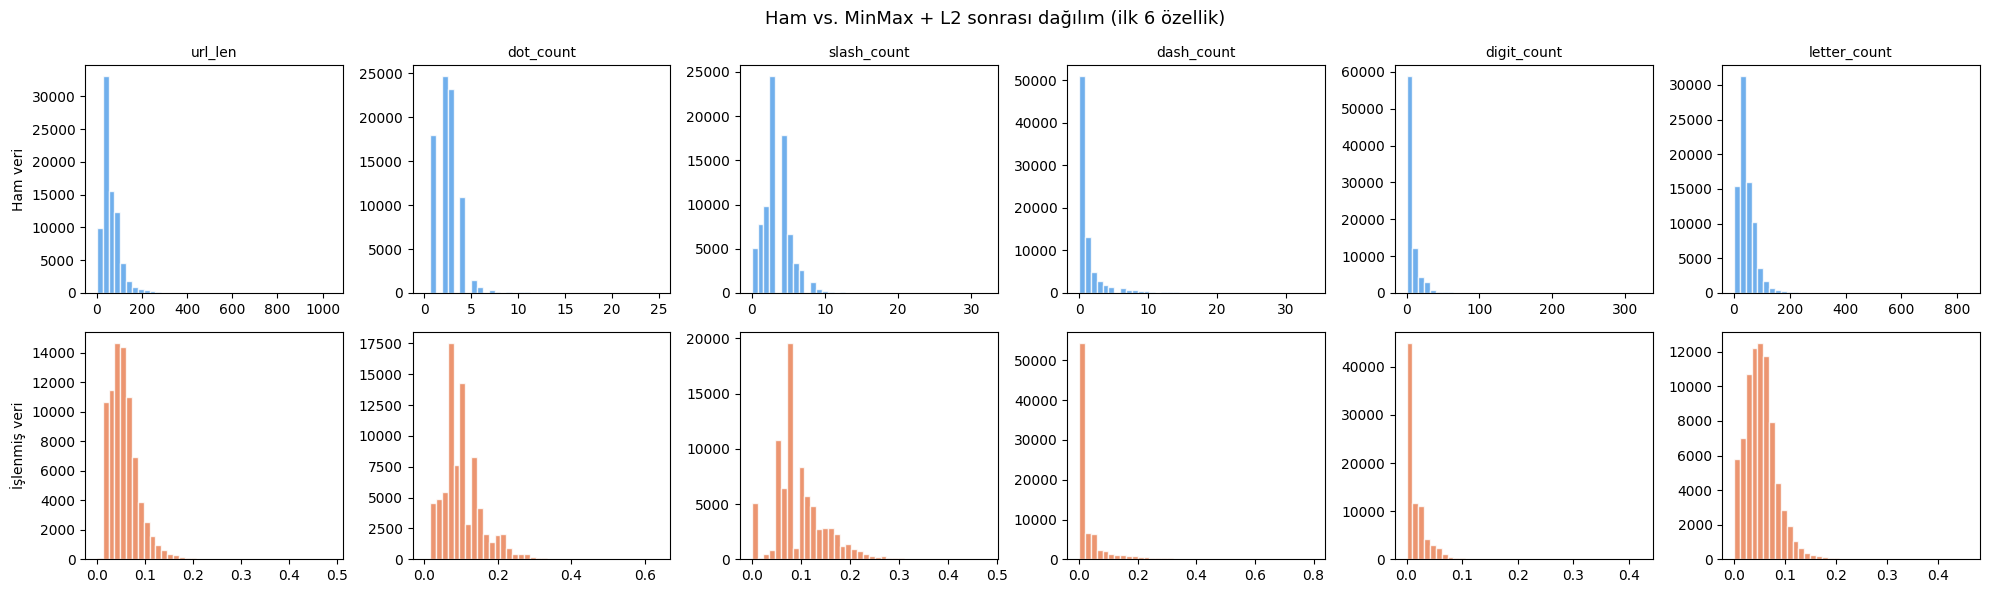

In [28]:
fig, axes = plt.subplots(2, 6, figsize=(20, 6))

for col in range(6):
    axes[0, col].hist(X_train[:, col], bins=40, color='#4C9BE8', alpha=0.8, edgecolor='white')
    axes[0, col].set_title(feature_cols[col], fontsize=10)
    if col == 0:
        axes[0, col].set_ylabel('Ham veri', fontsize=10)

    axes[1, col].hist(X_train_proc[:, col], bins=40, color='#E87B4C', alpha=0.8, edgecolor='white')
    if col == 0:
        axes[1, col].set_ylabel('İşlenmiş veri', fontsize=10)

plt.suptitle('Ham vs. MinMax + L2 sonrası dağılım (ilk 6 özellik)', fontsize=13)
plt.tight_layout()
plt.show()

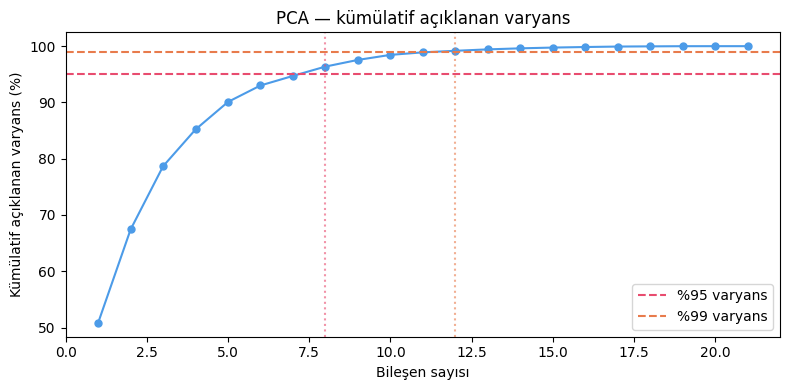

%95 varyans için gereken bileşen sayısı: 8
%99 varyans için gereken bileşen sayısı: 12


In [29]:
from sklearn.decomposition import PCA

pca_full = PCA(random_state=42).fit(X_train_proc)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumvar) + 1), cumvar * 100, marker='o', color='#4C9BE8', markersize=5)
plt.axhline(95, color='#E84C6F', linestyle='--', label='%95 varyans')
plt.axhline(99, color='#E87B4C', linestyle='--', label='%99 varyans')
n95 = int(np.argmax(cumvar >= 0.95)) + 1
n99 = int(np.argmax(cumvar >= 0.99)) + 1
plt.axvline(n95, color='#E84C6F', linestyle=':', alpha=0.6)
plt.axvline(n99, color='#E87B4C', linestyle=':', alpha=0.6)
plt.xlabel('Bileşen sayısı')
plt.ylabel('Kümülatif açıklanan varyans (%)')
plt.title('PCA — kümülatif açıklanan varyans')
plt.legend()
plt.tight_layout()
plt.show()

print(f'%95 varyans için gereken bileşen sayısı: {n95}')
print(f'%99 varyans için gereken bileşen sayısı: {n99}')

In [30]:
for fold_idx, (Xtr, Xval, ytr, yval) in enumerate(get_kfold_splits(X, y, n_splits=5)):
    print(f'Fold {fold_idx+1}: train={len(ytr):,}  val={len(yval):,}  '
          f'dağılım={dict(zip(*np.unique(yval, return_counts=True)))}')

Fold 1: train=80,000  val=20,000  dağılım={np.int64(0): np.int64(5000), np.int64(1): np.int64(5000), np.int64(2): np.int64(5000), np.int64(3): np.int64(5000)}
Fold 2: train=80,000  val=20,000  dağılım={np.int64(0): np.int64(5000), np.int64(1): np.int64(5000), np.int64(2): np.int64(5000), np.int64(3): np.int64(5000)}
Fold 3: train=80,000  val=20,000  dağılım={np.int64(0): np.int64(5000), np.int64(1): np.int64(5000), np.int64(2): np.int64(5000), np.int64(3): np.int64(5000)}
Fold 4: train=80,000  val=20,000  dağılım={np.int64(0): np.int64(5000), np.int64(1): np.int64(5000), np.int64(2): np.int64(5000), np.int64(3): np.int64(5000)}
Fold 5: train=80,000  val=20,000  dağılım={np.int64(0): np.int64(5000), np.int64(1): np.int64(5000), np.int64(2): np.int64(5000), np.int64(3): np.int64(5000)}


In [31]:
print('=' * 52)
print(f'  Ham veri       : {len(df_raw):>10,} URL')
print(f'  Örneklem       : {len(df):>10,} URL')
print(f'  Özellik sayısı : {X.shape[1]:>10}')
print(f'  Train          : {X_train_proc.shape[0]:>10,} örnek  {X_train_proc.shape}')
print(f'  Test           : {X_test_proc.shape[0]:>10,} örnek  {X_test_proc.shape}')
print('=' * 52)
print('\nModele hazır: X_train_proc, X_test_proc, y_train, y_test')

  Ham veri       :    651,191 URL
  Örneklem       :    100,000 URL
  Özellik sayısı :         21
  Train          :     80,000 örnek  (80000, 21)
  Test           :     20,000 örnek  (20000, 21)

Modele hazır: X_train_proc, X_test_proc, y_train, y_test


In [ ]:
os.makedirs('../data/processed', exist_ok=True)

# Dizileri kaydet
np.save('../data/processed/X_train.npy', X_train_proc)
np.save('../data/processed/X_test.npy',  X_test_proc)
np.save('../data/processed/y_train.npy', y_train)
np.save('../data/processed/y_test.npy',  y_test)

print('Kaydedilen dosyalar:')
for f in os.listdir('../data/processed'):
    path = os.path.join('../data/processed', f)
    print(f'  {path}  —  {os.path.getsize(path) / 1024:.1f} KB')

Kaydedilen dosyalar:


FileNotFoundError: [WinError 3] Sistem belirtilen yolu bulamıyor: 'data/processed'